# Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

## Purpose
This project analyses passenger demand and fare revenue for the
Kampala–Ntinda, Kampala–Entebbe and Kampala–Mukono taxi routes.
It compares forecasting methods and estimates vehicles needed for day 11.

## Data and assumptions
The assignment supplies ten daily passenger counts per route.
Fares are UGX 2,000 for Ntinda, UGX 5,000 for Entebbe and
UGX 3,000 for Mukono.

Passenger counts are treated as daily passenger journeys across each
route. Revenue is gross fare income before operating costs.
Forecast revenues assume fares remain unchanged.

## Approach
We summarise passengers and revenue, solve the illustrative Ntinda
supply–demand equations, and compare moving average, exponential
smoothing and linear trend forecasts using walk-forward evaluation.

Fleet planning assumes each vehicle makes eight one-way trips per day,
with 14 passengers per trip, and includes a 15% demand buffer.

In [1]:
import sys
from pathlib import Path
import numpy as np

# Locate the project folder so Python can import from src.
project_folder = Path.cwd()
if not (project_folder / "src").is_dir():
    project_folder = project_folder.parent

sys.path.insert(0, str(project_folder))

from src.taxi import Route

# Create each route using the assignment's passenger counts and fares.
routes = {
    "Kampala–Ntinda": Route(
        "Kampala–Ntinda",
        np.array([35, 40, 42, 50, 55, 60, 48, 52, 47, 45]),
        fare=2000
    ),
    "Kampala–Entebbe": Route(
        "Kampala–Entebbe",
        np.array([60, 58, 65, 70, 72, 80, 75, 68, 66, 64]),
        fare=5000
    ),
    "Kampala–Mukono": Route(
        "Kampala–Mukono",
        np.array([45, 47, 50, 49, 55, 62, 58, 53, 51, 50]),
        fare=3000
    )
}

# Check the observation count and total revenue for each route.
for name, route in routes.items():
    print(
        f"{name}: {len(route.passengers)} days, "
        f"total revenue = UGX {route.total_revenue():,.0f}"
    )

Kampala–Ntinda: 10 days, total revenue = UGX 948,000
Kampala–Entebbe: 10 days, total revenue = UGX 3,390,000
Kampala–Mukono: 10 days, total revenue = UGX 1,560,000


## 1. Summarise route demand and revenue

For each route, we calculate mean daily passenger journeys, population
variance and standard deviation across the ten recorded days.

Revenue equals passenger journeys multiplied by the route's fixed fare.
Revenue differences therefore reflect both passenger numbers and fares;
they do not establish which route is most profitable.

In [2]:
import pandas as pd

# Collect passenger statistics and revenue totals for each route.
summary_rows = []

for name, route in routes.items():
    passenger_stats = route.passenger_statistics()

    summary_rows.append({
        "Route": name,
        "Mean daily passengers": passenger_stats["Mean"],
        "Passenger variance": passenger_stats["Variance"],
        "Passenger SD": passenger_stats["Standard deviation"],
        "Fare (UGX)": route.fare,
        "Total revenue (UGX)": route.total_revenue(),
        "Mean daily revenue (UGX)": float(np.mean(route.daily_revenue()))
    })

# Display the comparison, rounding only the displayed values.
route_summary = pd.DataFrame(summary_rows)
display(route_summary.round(2))

,Route,Mean daily passengers,Passenger variance,Passenger SD,Fare (UGX),Total revenue (UGX),Mean daily revenue (UGX)
0,Kampala–Ntinda,47.4,48.84,6.99,2000.0,948000.0,94800.0
1,Kampala–Entebbe,67.8,40.56,6.37,5000.0,3390000.0,339000.0
2,Kampala–Mukono,52.0,23.80,4.88,3000.0,1560000.0,156000.0


## 2. Find the illustrative equilibrium fare

The assignment defines demand and supply as:

Qd = 120 − 0.02P
Qs = 10 + 0.03P

At equilibrium, demand and supply equal the same quantity Q.
Rearranging gives:

0.02P + Q = 120
−0.03P + Q = 10

P is the fare in UGX, and Q is passengers per trip-hour.
These quantities differ from the daily passenger counts used elsewhere.

In [3]:
from scipy.linalg import solve

# Arrange the equations with unknowns ordered as fare P, then quantity Q.
coefficients = np.array([
    [0.02, 1.0],
    [-0.03, 1.0]
])
constants = np.array([120.0, 10.0])

# Solve for the equilibrium fare and passenger quantity.
equilibrium_fare, equilibrium_quantity = solve(coefficients, constants)

# Evaluate demand and supply at the current Ntinda fare.
current_fare = routes["Kampala–Ntinda"].fare
current_demand = 120 - 0.02 * current_fare
current_supply = 10 + 0.03 * current_fare

print(f"Equilibrium fare: UGX {equilibrium_fare:,.2f}")
print(f"Equilibrium quantity: {equilibrium_quantity:.2f} passengers per trip-hour")
print(f"Demand at current fare: {current_demand:.2f}")
print(f"Supply at current fare: {current_supply:.2f}")
print(f"Excess demand: {current_demand - current_supply:.2f} passengers per trip-hour")

Equilibrium fare: UGX 2,200.00
Equilibrium quantity: 76.00 passengers per trip-hour
Demand at current fare: 80.00
Supply at current fare: 70.00
Excess demand: 10.00 passengers per trip-hour


### Interpretation of the equilibrium fare

The current Ntinda fare of UGX 2,000 is UGX 200 below the model's
equilibrium fare of UGX 2,200. At the current fare, predicted demand
is 80 passengers per trip-hour while supply is 70, leaving excess
demand of 10 passengers per trip-hour.

At UGX 2,200, both equations give 76 passengers per trip-hour,
so the illustrative market clears.

These equations are supplied assumptions, not relationships estimated
from the ten-day passenger dataset. The result therefore does not
establish that raising the actual fare would produce these outcomes.
Subsequent revenue forecasts retain the assignment's original fares.

## 3. Compare next-day forecasting methods

The three-day moving average uses the latest three observations.
Exponential smoothing updates a demand level using a weighting
parameter, alpha. Linear trend fits a straight line to all available
historical observations and extends it by one day.

We first forecast Ntinda's day 4 using only days 1–3.
Alpha is temporarily set to 0.5; it will be tuned later.
Forecasts remain unrounded because expected demand can be fractional.

In [4]:
import importlib
import src.taxi as taxi_module

# Reload the module to access the three forecasting subclasses.
importlib.reload(taxi_module)

# Use only the first three days to predict day 4.
ntinda_history = routes["Kampala–Ntinda"].passengers[:3]

# Create one instance of each forecasting method.
trial_models = {
    "Moving average": taxi_module.MovingAverageForecaster(),
    "Exponential smoothing": taxi_module.ExponentialSmoothingForecaster(
        alpha=0.5
    ),
    "Linear trend": taxi_module.LinearTrendForecaster()
}

# Display each prediction alongside the held-out observation.
for name, model in trial_models.items():
    print(f"{name}: {model.predict(ntinda_history):.2f} passengers")

print("Actual day 4 passengers:", routes["Kampala–Ntinda"].passengers[3])

Moving average: 39.00 passengers
Exponential smoothing: 39.75 passengers
Linear trend: 46.00 passengers
Actual day 4 passengers: 50.0


## 4. Tune exponential smoothing with walk-forward validation

For each route, we try alpha values from 0.1 to 1.0 and calculate
one-day-ahead MAE across days 4–10. Each prediction uses only earlier
observations. The alpha with the lowest validation MAE is selected.

These seven days are used for tuning and model comparison, so the
selected score is a validation result, not an independent test estimate.        

In [5]:
# Reload the module to access the walk-forward evaluation function.
importlib.reload(taxi_module)

# Try ten smoothing weights and store the best one for each route.
alpha_grid = np.linspace(0.1, 1.0, 10)
best_alphas = {}

for route_name, route in routes.items():
    alpha_scores = []

    # Evaluate each alpha using forecasts for days 4–10.
    for alpha in alpha_grid:
        model = taxi_module.ExponentialSmoothingForecaster(
            alpha=float(alpha)
        )
        predictions, mae = taxi_module.walk_forward(
            model, route.passengers
        )
        alpha_scores.append(mae)

    # Select the lowest MAE; ties favour the first, smaller alpha.
    best_position = int(np.argmin(alpha_scores))
    best_alphas[route_name] = float(alpha_grid[best_position])

    print(
        f"{route_name}: "
        f"best alpha = {best_alphas[route_name]:.1f}, "
        f"validation MAE = {alpha_scores[best_position]:.2f} passengers"
    )

Kampala–Ntinda: best alpha = 1.0, validation MAE = 5.86 passengers
Kampala–Entebbe: best alpha = 1.0, validation MAE = 4.43 passengers
Kampala–Mukono: best alpha = 1.0, validation MAE = 3.71 passengers


In [6]:
# Store model scores and predictions for days 4–10.
comparison_rows = []
validation_predictions = {}

for route_name, route in routes.items():
    # Use the selected alpha for each route's smoothing model.
    models = {
        "Moving average": taxi_module.MovingAverageForecaster(),
        "Exponential smoothing": taxi_module.ExponentialSmoothingForecaster(
            alpha=best_alphas[route_name]
        ),
        "Linear trend": taxi_module.LinearTrendForecaster()
    }

    validation_predictions[route_name] = {}

    # Evaluate every model over the same seven days.
    for model_name, model in models.items():
        predictions, mae = taxi_module.walk_forward(
            model, route.passengers
        )

        validation_predictions[route_name][model_name] = predictions
        comparison_rows.append({
            "Route": route_name,
            "Model": model_name,
            "MAE (passengers)": mae
        })

# Display each route's model errors side by side.
comparison_table = pd.DataFrame(comparison_rows)

display(comparison_table.pivot(
    index="Route",
    columns="Model",
    values="MAE (passengers)"
).round(2))

Model,Exponential smoothing,Linear trend,Moving average
Route,,,
Kampala–Entebbe,4.43,7.71,7.19
Kampala–Mukono,3.71,6.39,5.33
Kampala–Ntinda,5.86,7.87,7.52


## 5. Forecast day 11 passengers and revenue

For each route, we select the model with the lowest unrounded
walk-forward MAE and forecast day 11 using all ten observed days.

Exponential smoothing performed best for all three routes, with
alpha = 1.0. Its forecasts therefore equal the latest passenger counts.
Revenue forecasts use the original fares and exclude operating costs.

In [7]:
# Store the selected models and day 11 forecasts.
selected_models = {}
day11_passengers = {}
forecast_rows = []

for route_name, route in routes.items():
    # Find the model with the lowest validation MAE for this route.
    route_scores = comparison_table.loc[
        comparison_table["Route"] == route_name
    ]
    best_position = int(np.argmin(
        route_scores["MAE (passengers)"].to_numpy()
    ))
    best_name = str(route_scores.iloc[best_position]["Model"])

    # Create the selected model with its appropriate settings.
    models = {
        "Moving average": taxi_module.MovingAverageForecaster(),
        "Exponential smoothing": taxi_module.ExponentialSmoothingForecaster(
            alpha=best_alphas[route_name]
        ),
        "Linear trend": taxi_module.LinearTrendForecaster()
    }
    selected_models[route_name] = best_name

    # Forecast passenger journeys, then convert them to gross revenue.
    prediction = models[best_name].predict(route.passengers)
    day11_passengers[route_name] = prediction

    forecast_rows.append({
        "Route": route_name,
        "Selected model": best_name,
        "Day 11 passengers": prediction,
        "Day 11 revenue (UGX)": prediction * route.fare
    })

display(pd.DataFrame(forecast_rows).round(2))

,Route,Selected model,Day 11 passengers,Day 11 revenue (UGX)
0,Kampala–Ntinda,Exponential smoothing,45.0,90000.0
1,Kampala–Entebbe,Exponential smoothing,64.0,320000.0
2,Kampala–Mukono,Exponential smoothing,50.0,150000.0


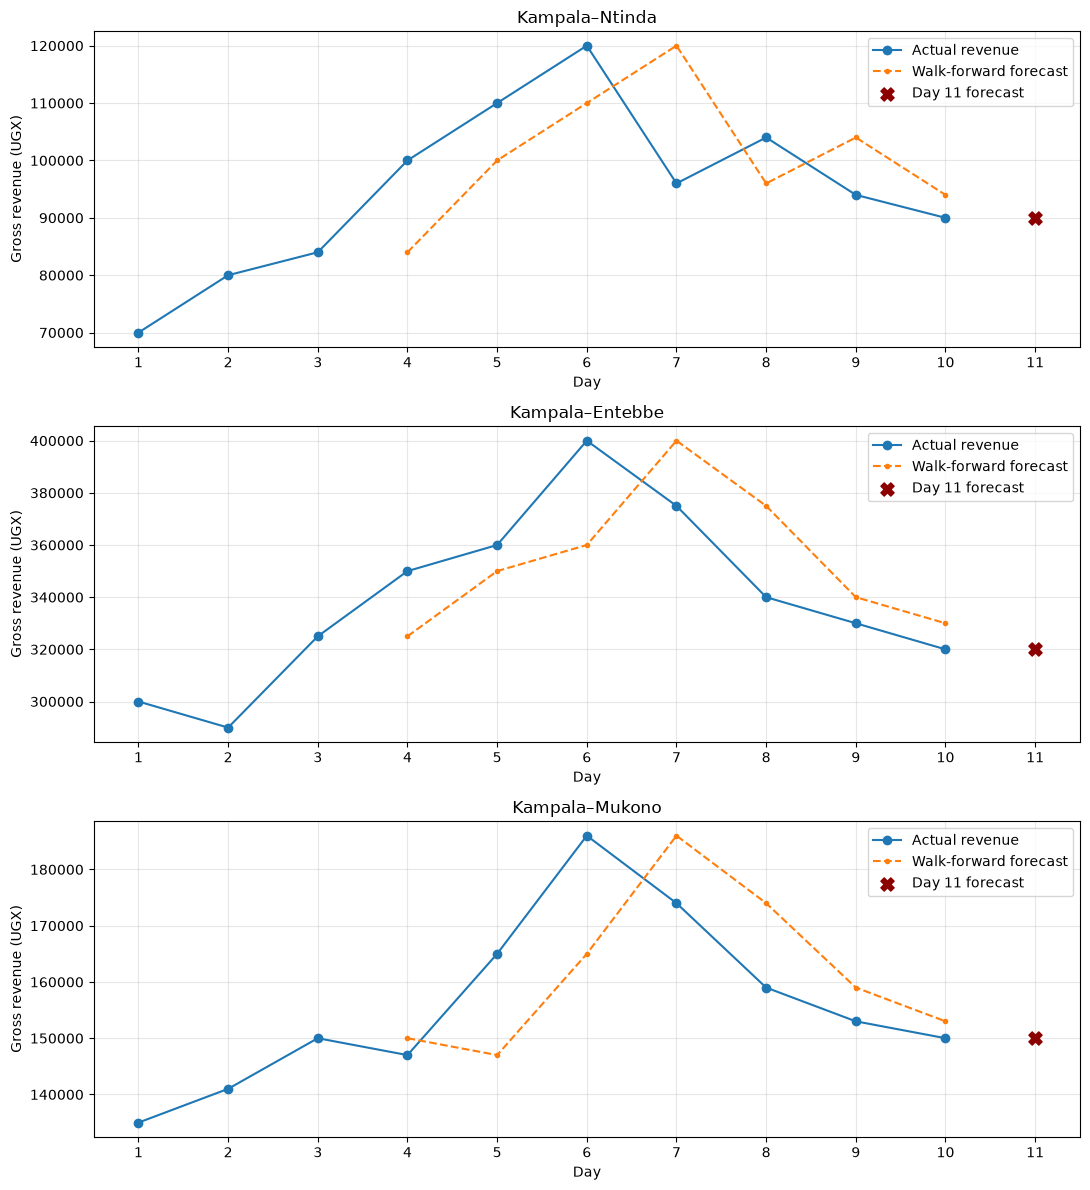

In [8]:
import matplotlib.pyplot as plt

# Create a separate revenue chart for each route.
fig, axes = plt.subplots(3, 1, figsize=(11, 12))

for ax, (route_name, route) in zip(axes, routes.items()):
    actual_days = np.arange(1, len(route.passengers) + 1)
    best_name = selected_models[route_name]

    # Convert the selected model's validation predictions into revenue.
    validation_revenue = (
        validation_predictions[route_name][best_name] * route.fare
    )
    forecast_revenue = day11_passengers[route_name] * route.fare

    # Show observed revenue and one-day-ahead validation forecasts.
    ax.plot(
        actual_days, route.daily_revenue(),
        marker="o", label="Actual revenue"
    )
    ax.plot(
        actual_days[3:], validation_revenue,
        linestyle="--", marker=".",
        label="Walk-forward forecast"
    )

    # Mark day 11 separately because its actual revenue is unknown.
    ax.scatter(
        11, forecast_revenue, color="darkred",
        marker="X", s=90, label="Day 11 forecast", zorder=5
    )

    ax.set_title(route_name)
    ax.set_xlabel("Day")
    ax.set_ylabel("Gross revenue (UGX)")
    ax.set_xticks(np.arange(1, 12))
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Plan vehicle requirements

Each vehicle can serve 8 × 14 = 112 passenger journeys per day,
assuming every trip operates at full capacity.

We increase forecast demand by 15%, divide by daily vehicle capacity,
and round upward to a whole vehicle. The buffer is applied before rounding.

This is a daily capacity estimate. It does not account for peak-hour
crowding, travel times, uneven demand by direction or vehicle downtime.

In [9]:
# Calculate daily passenger capacity per vehicle.
trips_per_day = 8
seats_per_vehicle = 14
daily_capacity = trips_per_day * seats_per_vehicle
demand_buffer = 0.15

fleet_rows = []

for route_name, prediction in day11_passengers.items():
    # Increase forecast demand by 15% before calculating the fleet.
    buffered_demand = prediction * (1 + demand_buffer)
    vehicles_needed = int(np.ceil(buffered_demand / daily_capacity))

    fleet_rows.append({
        "Route": route_name,
        "Forecast passengers": prediction,
        "Passengers with 15% buffer": buffered_demand,
        "Daily capacity per vehicle": daily_capacity,
        "Vehicles needed": vehicles_needed
    })

# Display the vehicle requirement for each route.
fleet_table = pd.DataFrame(fleet_rows)
display(fleet_table.round(2))

,Route,Forecast passengers,Passengers with 15% buffer,Daily capacity per vehicle,Vehicles needed
0,Kampala–Ntinda,45.0,51.75,112,1
1,Kampala–Entebbe,64.0,73.60,112,1
2,Kampala–Mukono,50.0,57.50,112,1
